In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import skimage.metrics as metrics
cv2.useOptimized() 
import urllib.request

/var/folders/n3/w2kc2s3d6t76l6jbt7gd52tc0000gn/T/ipykernel_25602/3990753644.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(imgray.ravel(),256,[0,256])


Text(0.5, 1.0, 'Histogram of Grayscale Image')

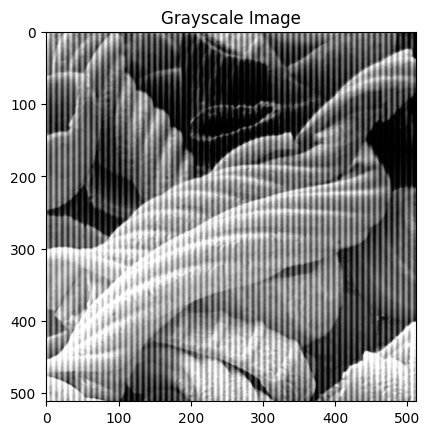

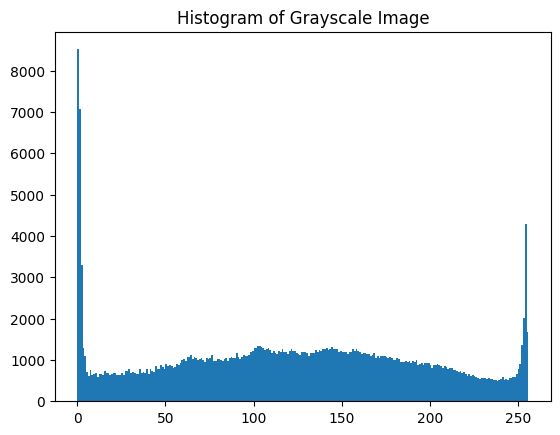

In [ ]:
# read sample image from url

im=cv2.imread('./data/kodim07.png')
im=cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
imgray=cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
plt.figure()
plt.imshow(imgray, cmap='gray')
plt.title('Grayscale Image')

#plot image istogram 
plt.figure()
plt.hist(imgray.ravel(),256,[0,256])
plt.title('Histogram of Grayscale Image')

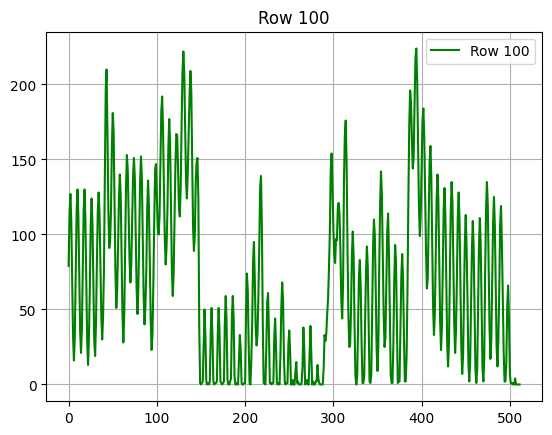

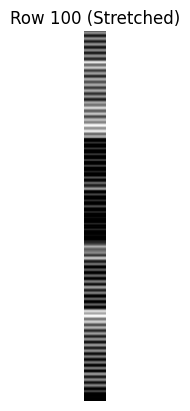

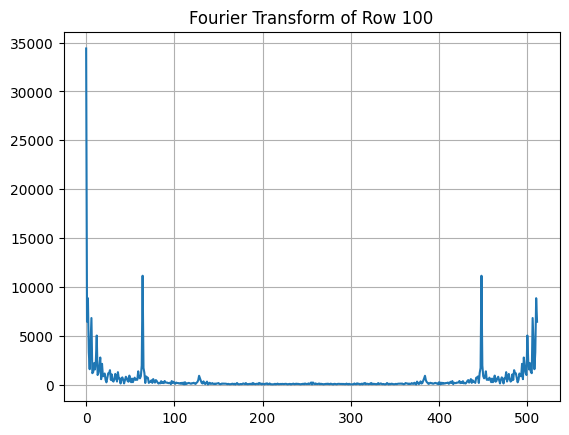

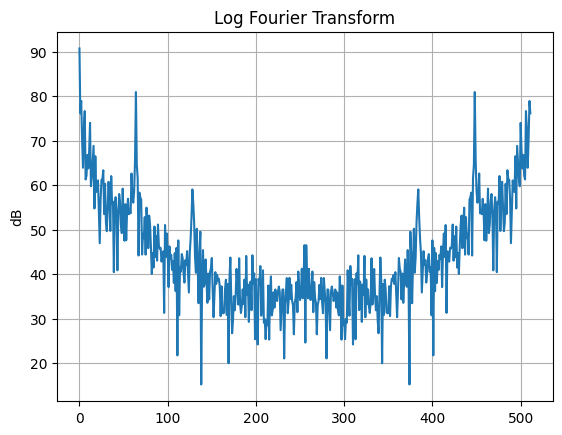

In [3]:
im_row=imgray[100,:] # row 100
plt.figure()
plt.plot(im_row, 'g', label='Row 100')
plt.title('Row 100')
plt.grid()
plt.legend()

# plot the row of the image (pixel colored with the respective gray value)
im_row_color = np.zeros((im_row.shape[0], 3), dtype=np.uint8)
im_row_color[:, 0] = im_row  # Set R to the gray value
im_row_color[:, 1] = im_row  # Set G to the gray value
im_row_color[:, 2] = im_row  # Set B to the gray value
plt.figure()
plt.imshow(im_row_color, cmap='gray', aspect=0.1)
plt.title('Row 100 (Stretched)')
plt.axis('off')



F=np.fft.fft(im_row)
plt.figure()
plt.plot(np.abs(F))
plt.title('Fourier Transform of Row 100')
plt.grid()


plt.figure()
plt.plot(20*np.log10(np.abs(F)))
plt.title('Log Fourier Transform')
plt.ylabel('dB')
plt.grid()

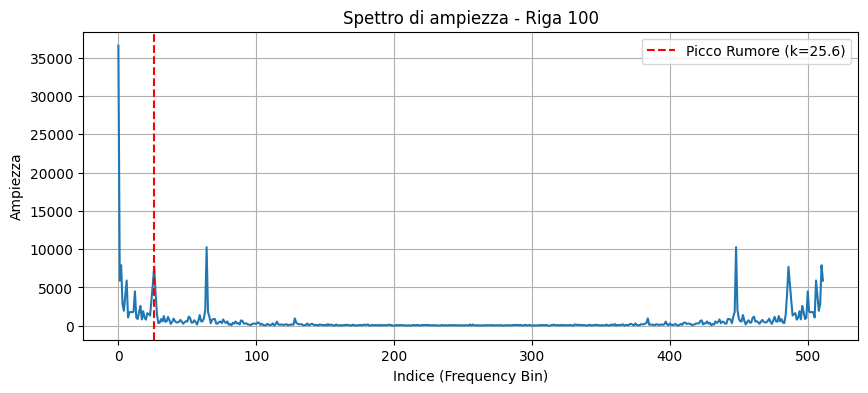

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parametri
f_noise = 1/20  # Frequenza: 1 ciclo ogni 20 pixel
A = 50          # Ampiezza del rumore 

# 2. Generazione Rumore
x = np.arange(imgray.shape[1])
# Creiamo il segnale sinusoidale
sin_noise = A * np.sin(2 * np.pi * f_noise * x)
noise_matrix = np.tile(sin_noise, (imgray.shape[0], 1))

im_noisy = imgray + noise_matrix
im_noisy = np.clip(im_noisy, 0, 255).astype(np.uint8)

# 3. Analisi di Fourier (su una riga)
row_idx = 100
row_data = im_noisy[row_idx, :]
N = len(row_data)

F_noisy = np.fft.fft(row_data)
# Calcoliamo le frequenze corrispondenti ai vari bin della FFT
freqs = np.fft.fftfreq(N) 

# 4. Identificazione dell'indice del rumore
# La frequenza f_noise si troverà all'indice: k = f_noise * N
target_idx = f_noise * N

plt.figure(figsize=(10, 4))
# Mostriamo solo la prima metà (frequenze positive) per chiarezza
plt.plot(np.abs(F_noisy)) 
plt.title(f'Spettro di ampiezza - Riga {row_idx}')
plt.axvline(x=target_idx, color='r', linestyle='--', label=f'Picco Rumore (k={target_idx:.1f})')
plt.xlabel('Indice (Frequency Bin)')
plt.ylabel('Ampiezza')
plt.legend()
plt.grid(True)
plt.show()

/var/folders/n3/w2kc2s3d6t76l6jbt7gd52tc0000gn/T/ipykernel_25602/1054493557.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.plot(20*np.log10(np.abs(Fapprox)))


MSE:  373.9039325932581
PSNR:  22.403203279293365


/var/folders/n3/w2kc2s3d6t76l6jbt7gd52tc0000gn/T/ipykernel_25602/1054493557.py:17: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr=metrics.peak_signal_noise_ratio(im_row, np.abs(row_approx))


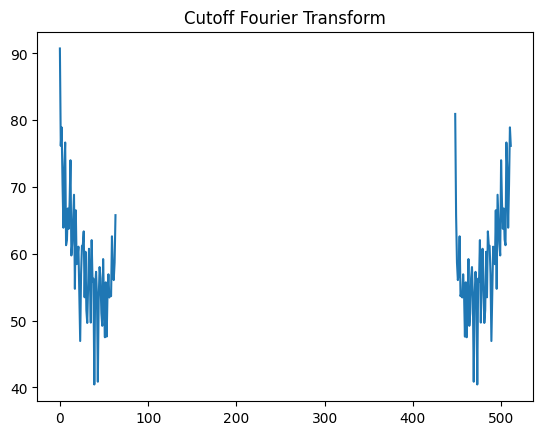

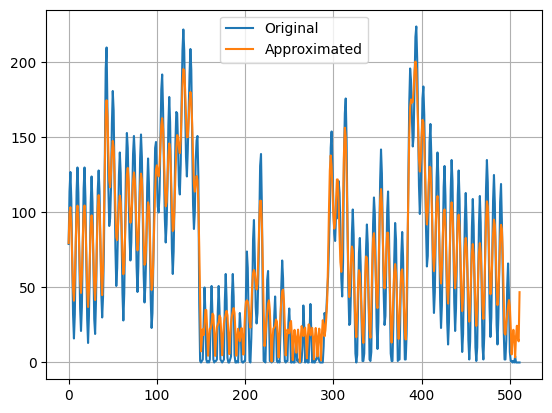

In [5]:
#set to zero half of the high frequencies
Fapprox=F.copy()
Fapprox[int(Fapprox.size/8):int(Fapprox.size/8*7)]=0

plt.figure()
plt.plot(20*np.log10(np.abs(Fapprox)))
plt.title('Cutoff Fourier Transform')

row_approx=np.fft.ifft(Fapprox)
plt.figure()
plt.plot(im_row)
plt.plot(np.abs(row_approx))
plt.legend(['Original','Approximated'])
plt.grid()

mse=metrics.mean_squared_error(im_row, np.abs(row_approx))
psnr=metrics.peak_signal_noise_ratio(im_row, np.abs(row_approx))

print('MSE: ', mse)
print('PSNR: ', psnr)



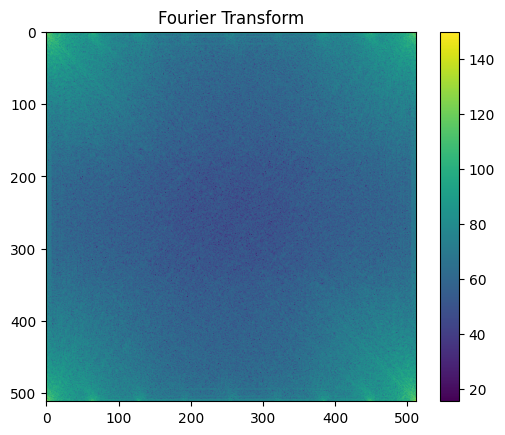

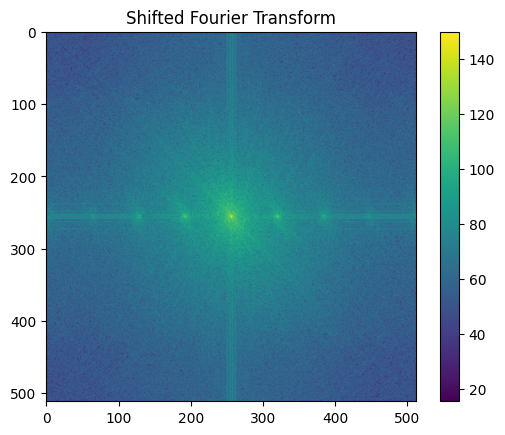

In [6]:
#implement DFT2d

#fft along rows
F2d_rows=np.fft.fft(imgray, axis=1)
#fft along columns
F2d_cols_rows=np.fft.fft(F2d_rows, axis=0)

plt.figure()
plt.imshow(20*np.log10(np.abs(F2d_cols_rows)))
plt.title('Fourier Transform')
plt.colorbar()

F2d_shifted=np.fft.fftshift(F2d_cols_rows)
plt.figure()    
plt.imshow(20*np.log10(np.abs(F2d_shifted)))
plt.title('Shifted Fourier Transform')
plt.colorbar()

In [ ]:
#generate random image with a (1/f)ˆgamma spectrum shape
def generate_fractal_spectrum(size=512, gamma=1.0):
    # Create frequency meshgrid
    U,V=np.meshgrid(np.arange(size),np.arange(size))
    epsilon=1e-4
    
    # Compute fractal spectrum
    F_uv = 1 / ((U-size//2)**2 + (V-size//2)**2 + epsilon)**gamma

    #generate random noise N(0,1)
    noise=np.random.randn(size,size)
    
    
    # Compute Fourier domain representation
    spectrum = F_uv * noise*np.exp(1j*np.pi*noise)
    spectrum=np.fft.ifftshift(spectrum)
    
    image = np.fft.ifft2(spectrum).real
    image = (image - np.min(image)) / (np.max(image) - np.min(image))*255
    image = image.astype(np.uint8)
    
    return image

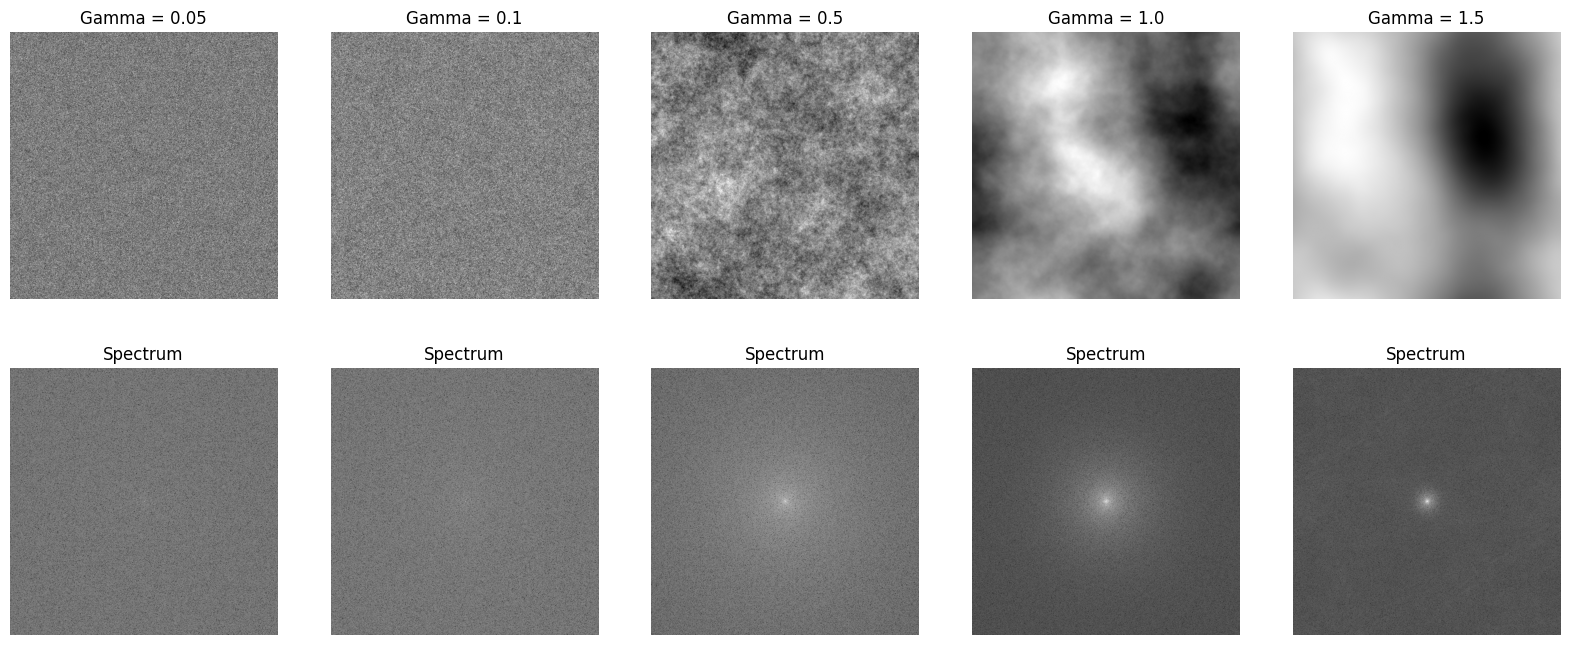

In [ ]:
# generate fractal spectrum image with gamma=0.05, 0.1, 0.5, 1.0, 1.5 and stich them together
image1 = generate_fractal_spectrum(size=512, gamma=0.05)
image2 = generate_fractal_spectrum(size=512, gamma=0.1)
image3 = generate_fractal_spectrum(size=512, gamma=0.5)
image4 = generate_fractal_spectrum(size=512, gamma=1.0)
image5 = generate_fractal_spectrum(size=512, gamma=1.5)

fig, ax = plt.subplots(2, 5, figsize=(20, 8))
images = [image1, image2, image3, image4, image5]
gammas = [0.05, 0.1, 0.5, 1.0, 1.5]
for i in range(5):
    ax[0,i].imshow(images[i], cmap='gray')
    ax[0,i].set_title(f'Gamma = {gammas[i]}')
    ax[0,i].axis('off')
    spectrum=np.fft.fftshift(np.fft.fft2(images[i]))
    ax[1,i].imshow(np.log10(np.abs(spectrum)), cmap='gray')
    ax[1,i].set_title(f'Spectrum')
    ax[1,i].axis('off')
plt.show()


